In [1]:
import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import itertools
import functionsTP as myfunc

ACTIVE CONTOUR WITH BALLOON FORCE (CONTRACTION FOCUSED)
Testing 12 parameter combinations (focused on contraction):
----------------------------------------------------------------------
Alpha    Beta     Gamma    Kappa    Dice     Iterations  
----------------------------------------------------------------------
0.10     0.10     1.50     -0.30    0.8736   200         
0.10     0.10     1.50     -0.50    0.8736   200         
0.10     0.10     2.00     -0.30    0.8768   200         
0.10     0.10     2.00     -0.50    0.8768   200         
0.10     0.20     1.50     -0.30    0.8736   200         
0.10     0.20     1.50     -0.50    0.8736   200         
0.10     0.20     2.00     -0.30    0.8768   200         
0.10     0.20     2.00     -0.50    0.8768   200         
0.20     0.10     1.50     -0.30    0.8729   200         
0.20     0.10     1.50     -0.50    0.8729   200         
0.20     0.10     2.00     -0.30    0.8744   200         
0.20     0.10     2.00     -0.50    0.8744   2

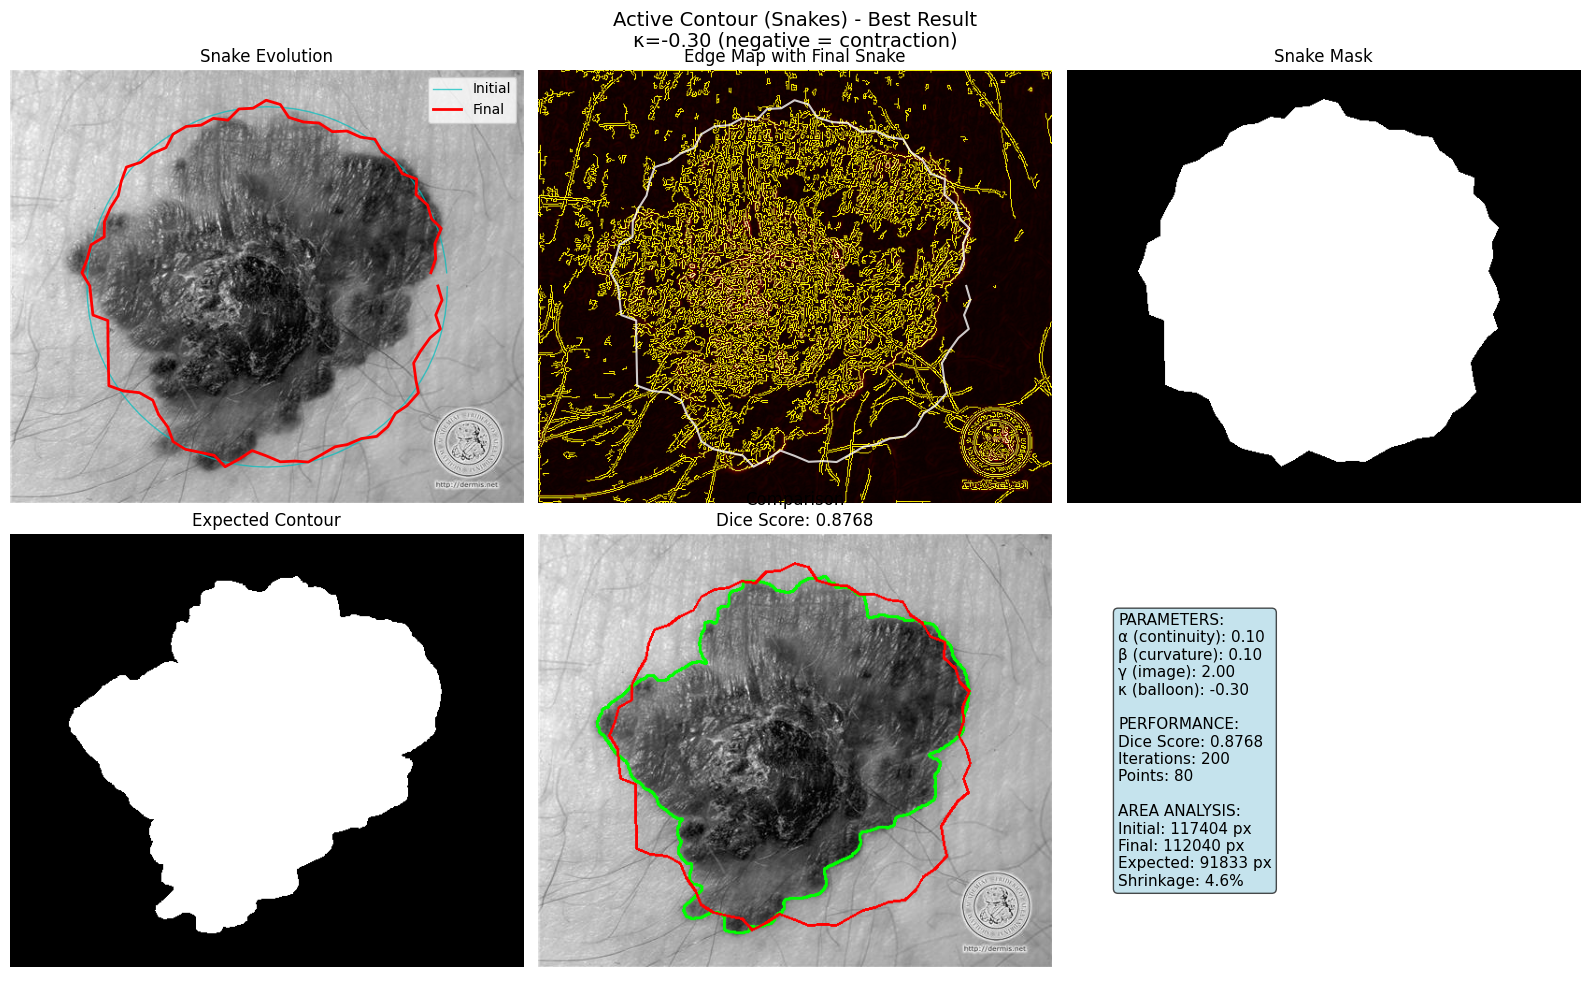

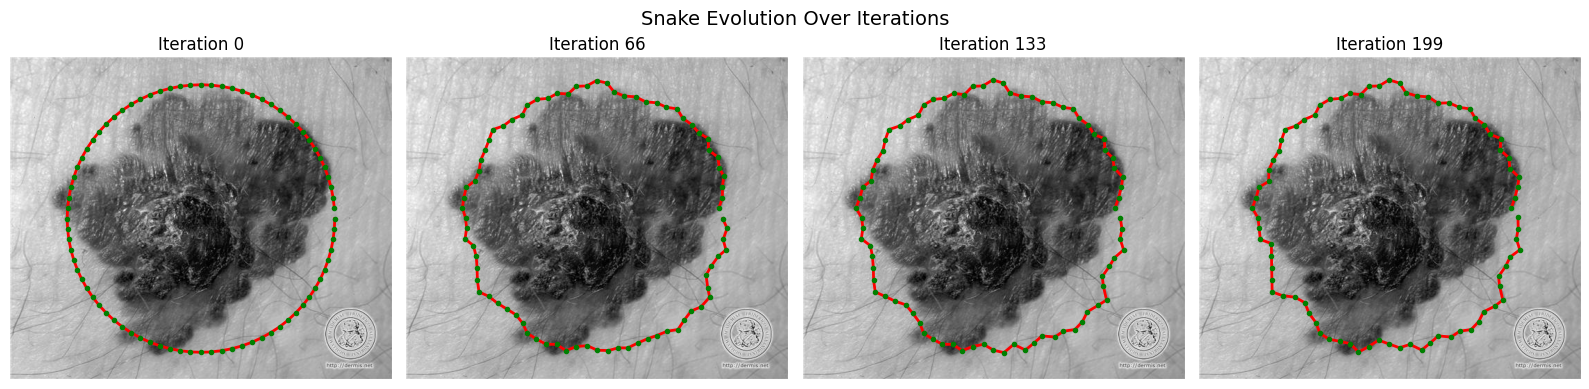

In [ ]:
image_orig = r'images\skin-waterloo\SSM33_orig.jpg'
# image_orig = r'images\skin-waterloo\SSM33_contour.png'
image_contour = r'images\skin-waterloo\SSM33_contour.png'

img_bgr = cv2.imread(image_orig)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

contour_img = cv2.imread(image_contour, cv2.IMREAD_GRAYSCALE)

if contour_img.max() > 0:
    _, expected_mask = cv2.threshold(contour_img, 127, 255, cv2.THRESH_BINARY)
else:
    expected_mask = np.zeros_like(img_gray)

initial_points =  myfunc.initialize_snake_from_image(img_gray.shape, n_points=80)

# Test different parameter combinations
print("=" * 70)
print("ACTIVE CONTOUR WITH BALLOON FORCE (CONTRACTION FOCUSED)")
print("=" * 70)

best_result, all_results =  myfunc.test_parameter_combinations(img_gray, initial_points, expected_mask)

# Plot the best result
print("\n" + "=" * 70)
print("VISUALIZING BEST RESULT")
print("=" * 70)

fig1, fig2 =  myfunc.plot_best_result(img_gray, best_result, expected_mask, initial_points)

# Print detailed summary
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"Best parameters found:")
print(f"  Alpha (continuity weight): {best_result['alpha']:.2f}")
print(f"  Beta (curvature weight): {best_result['beta']:.2f}")
print(f"  Gamma (image energy weight): {best_result['gamma']:.2f}")
print(f"  Kappa (balloon force): {best_result['kappa']:.2f} (negative = contracts)")

initial_mask =  myfunc.create_mask_from_contour(initial_points, img_gray.shape)
initial_area = np.sum(initial_mask > 0)
final_area = np.sum(best_result['snake_mask'] > 0)
expected_area = np.sum(expected_mask > 0)

print(f"\nArea analysis:")
print(f"  Initial snake area: {initial_area:.0f} pixels")
print(f"  Final snake area: {final_area:.0f} pixels")
print(f"  Expected area: {expected_area:.0f} pixels")
print(f"  Area reduction: {100*(initial_area-final_area)/initial_area:.1f}%")
print(f"  Area error: {100*abs(final_area-expected_area)/expected_area:.1f}%")

print(f"\nPerformance metrics:")
print(f"  Dice Score: {best_result['dice']:.4f}")
print(f"  Iterations: {best_result['iterations']}")

print(f"\nAll results sorted by Dice score:")
print("-" * 70)
print(f"{'Rank':<6} {'Alpha':<8} {'Beta':<8} {'Gamma':<8} {'Kappa':<8} {'Dice':<8} {'Iterations':<12}")
print("-" * 70)

sorted_results = sorted(all_results, key=lambda x: x['dice'], reverse=True)
for rank, result in enumerate(sorted_results, 1):
    print(f"{rank:<6} {result['alpha']:<8.2f} {result['beta']:<8.2f} "
            f"{result['gamma']:<8.2f} {result['kappa']:<8.2f} "
            f"{result['dice']:<8.4f} {result['iterations']:<12}")

plt.show()